# Air Traffic Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("../Dataset/Air_Traffic.csv")

In [3]:
df

,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,Adjusted Activity Type Code,Adjusted Passenger Count,Year,Month
0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July
1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July
2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July
3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July
4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15002,201603,Virgin America,VX,Virgin America,VX,Domestic,US,Enplaned,Low Fare,Terminal 2,D,194636,Enplaned,194636,2016,March
15003,201603,Virgin America,VX,Virgin America,VX,International,Mexico,Deplaned,Low Fare,International,A,4189,Deplaned,4189,2016,March
15004,201603,Virgin America,VX,Virgin America,VX,International,Mexico,Enplaned,Low Fare,Terminal 2,D,4693,Enplaned,4693,2016,March
15005,201603,Virgin Atlantic,VS,Virgin Atlantic,VS,International,Europe,Deplaned,Other,International,A,12313,Deplaned,12313,2016,March


## Data prepration and cleaning

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15007 entries, 0 to 15006
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Activity Period              15007 non-null  int64 
 1   Operating Airline            15007 non-null  object
 2   Operating Airline IATA Code  14953 non-null  object
 3   Published Airline            15007 non-null  object
 4   Published Airline IATA Code  14953 non-null  object
 5   GEO Summary                  15007 non-null  object
 6   GEO Region                   15007 non-null  object
 7   Activity Type Code           15007 non-null  object
 8   Price Category Code          15007 non-null  object
 9   Terminal                     15007 non-null  object
 10  Boarding Area                15007 non-null  object
 11  Passenger Count              15007 non-null  int64 
 12  Adjusted Activity Type Code  15007 non-null  object
 13  Adjusted Passenger Count     15

In [5]:
df.dtypes

Activity Period                 int64
Operating Airline              object
Operating Airline IATA Code    object
Published Airline              object
Published Airline IATA Code    object
GEO Summary                    object
GEO Region                     object
Activity Type Code             object
Price Category Code            object
Terminal                       object
Boarding Area                  object
Passenger Count                 int64
Adjusted Activity Type Code    object
Adjusted Passenger Count        int64
Year                            int64
Month                          object
dtype: object

In [6]:
df.columns = df.columns.str.replace(" ","")

In [7]:
df

,ActivityPeriod,OperatingAirline,OperatingAirlineIATACode,PublishedAirline,PublishedAirlineIATACode,GEOSummary,GEORegion,ActivityTypeCode,PriceCategoryCode,Terminal,BoardingArea,PassengerCount,AdjustedActivityTypeCode,AdjustedPassengerCount,Year,Month
0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July
1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July
2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July
3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July
4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15002,201603,Virgin America,VX,Virgin America,VX,Domestic,US,Enplaned,Low Fare,Terminal 2,D,194636,Enplaned,194636,2016,March
15003,201603,Virgin America,VX,Virgin America,VX,International,Mexico,Deplaned,Low Fare,International,A,4189,Deplaned,4189,2016,March
15004,201603,Virgin America,VX,Virgin America,VX,International,Mexico,Enplaned,Low Fare,Terminal 2,D,4693,Enplaned,4693,2016,March
15005,201603,Virgin Atlantic,VS,Virgin Atlantic,VS,International,Europe,Deplaned,Other,International,A,12313,Deplaned,12313,2016,March


In [8]:
df.isnull().sum()

ActivityPeriod               0
OperatingAirline             0
OperatingAirlineIATACode    54
PublishedAirline             0
PublishedAirlineIATACode    54
GEOSummary                   0
GEORegion                    0
ActivityTypeCode             0
PriceCategoryCode            0
Terminal                     0
BoardingArea                 0
PassengerCount               0
AdjustedActivityTypeCode     0
AdjustedPassengerCount       0
Year                         0
Month                        0
dtype: int64

In [9]:
df=df.drop(['OperatingAirlineIATACode','PublishedAirlineIATACode'],axis=1)
df

,ActivityPeriod,OperatingAirline,PublishedAirline,GEOSummary,GEORegion,ActivityTypeCode,PriceCategoryCode,Terminal,BoardingArea,PassengerCount,AdjustedActivityTypeCode,AdjustedPassengerCount,Year,Month
0,200507,ATA Airlines,ATA Airlines,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July
1,200507,ATA Airlines,ATA Airlines,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July
2,200507,ATA Airlines,ATA Airlines,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July
3,200507,Air Canada,Air Canada,International,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July
4,200507,Air Canada,Air Canada,International,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15002,201603,Virgin America,Virgin America,Domestic,US,Enplaned,Low Fare,Terminal 2,D,194636,Enplaned,194636,2016,March
15003,201603,Virgin America,Virgin America,International,Mexico,Deplaned,Low Fare,International,A,4189,Deplaned,4189,2016,March
15004,201603,Virgin America,Virgin America,International,Mexico,Enplaned,Low Fare,Terminal 2,D,4693,Enplaned,4693,2016,March
15005,201603,Virgin Atlantic,Virgin Atlantic,International,Europe,Deplaned,Other,International,A,12313,Deplaned,12313,2016,March


In [10]:
df.OperatingAirline.unique()

array(['ATA Airlines', 'Air Canada ', 'Air China', 'Air France',
       'Air New Zealand', 'AirTran Airways', 'Alaska Airlines',
       'All Nippon Airways', 'American Airlines',
       'American Eagle Airlines', 'Asiana Airlines',
       'Atlantic Southeast Airlines', 'BelAir Airlines',
       'British Airways', 'Cathay Pacific', 'China Airlines',
       'Delta Air Lines', 'EVA Airways', 'Frontier Airlines',
       'Hawaiian Airlines', 'Horizon Air ', 'Icelandair',
       'Independence Air', 'Japan Airlines', 'KLM Royal Dutch Airlines',
       'Korean Air Lines', 'Lufthansa German Airlines', 'Mesa Airlines',
       'Mexicana Airlines', 'Midwest Airlines', 'Northwest Airlines',
       'Philippine Airlines', 'Singapore Airlines', 'SkyWest Airlines',
       'Sun Country Airlines', 'TACA', 'US Airways', 'United Airlines',
       'United Airlines - Pre 07/01/2013', 'Virgin Atlantic',
       'WestJet Airlines', 'Boeing Company', 'Miami Air International',
       'Air Canada Jazz', 'Qantas A

In [11]:
df.OperatingAirline=df.OperatingAirline.replace({'United Airlines - Pre 07/01/2013':'United Airlines'})

In [12]:
df.PublishedAirline.unique()

array(['ATA Airlines', 'Air Canada ', 'Air China', 'Air France',
       'Air New Zealand', 'AirTran Airways', 'Alaska Airlines',
       'All Nippon Airways', 'American Airlines', 'Asiana Airlines',
       'Delta Air Lines', 'BelAir Airlines', 'British Airways',
       'Cathay Pacific', 'China Airlines', 'EVA Airways',
       'Frontier Airlines', 'Hawaiian Airlines', 'Icelandair',
       'Independence Air', 'Japan Airlines', 'KLM Royal Dutch Airlines',
       'Korean Air Lines', 'Lufthansa German Airlines', 'US Airways',
       'Mexicana Airlines', 'Midwest Airlines', 'Northwest Airlines',
       'Philippine Airlines', 'Singapore Airlines',
       'United Airlines - Pre 07/01/2013', 'Sun Country Airlines', 'TACA',
       'United Airlines', 'Virgin Atlantic', 'WestJet Airlines',
       'Boeing Company', 'Miami Air International', 'Qantas Airways',
       'Ameriflight', 'Spirit Airlines', 'Xtra Airways',
       'Evergreen International Airlines', 'Aeromexico',
       'JetBlue Airways ', '

In [13]:
df.PublishedAirline=df.PublishedAirline.replace({'United Airlines - Pre 07/01/2013':'United Airlines'})

In [14]:
print(df.GEOSummary.unique())

['Domestic' 'International']


In [15]:
print(df.GEORegion.unique())

['US' 'Canada' 'Asia' 'Europe' 'Australia / Oceania' 'Mexico'
 'Central America' 'Middle East' 'South America']


In [16]:
print(df.ActivityTypeCode.unique())

['Deplaned' 'Enplaned' 'Thru / Transit']


In [17]:
print(df.PriceCategoryCode.unique())

['Low Fare' 'Other']


In [18]:
print(df.Terminal.unique())

['Terminal 1' 'International' 'Terminal 3' 'Other' 'Terminal 2']


In [19]:
print(df.BoardingArea.unique())

['B' 'G' 'A' 'E' 'C' 'F' 'Other' 'D']


In [20]:
print(df.Month.unique())

['July' 'August' 'September' 'October' 'November' 'April' 'December'
 'January' 'February' 'March' 'May' 'June']


In [21]:
df.ActivityPeriod = pd.to_datetime(df.ActivityPeriod, format='%Y%m')

In [22]:
df

,ActivityPeriod,OperatingAirline,PublishedAirline,GEOSummary,GEORegion,ActivityTypeCode,PriceCategoryCode,Terminal,BoardingArea,PassengerCount,AdjustedActivityTypeCode,AdjustedPassengerCount,Year,Month
0,2005-07-01,ATA Airlines,ATA Airlines,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July
1,2005-07-01,ATA Airlines,ATA Airlines,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July
2,2005-07-01,ATA Airlines,ATA Airlines,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July
3,2005-07-01,Air Canada,Air Canada,International,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July
4,2005-07-01,Air Canada,Air Canada,International,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15002,2016-03-01,Virgin America,Virgin America,Domestic,US,Enplaned,Low Fare,Terminal 2,D,194636,Enplaned,194636,2016,March
15003,2016-03-01,Virgin America,Virgin America,International,Mexico,Deplaned,Low Fare,International,A,4189,Deplaned,4189,2016,March
15004,2016-03-01,Virgin America,Virgin America,International,Mexico,Enplaned,Low Fare,Terminal 2,D,4693,Enplaned,4693,2016,March
15005,2016-03-01,Virgin Atlantic,Virgin Atlantic,International,Europe,Deplaned,Other,International,A,12313,Deplaned,12313,2016,March


In [23]:
df.describe()

,ActivityPeriod,PassengerCount,AdjustedPassengerCount,Year
count,15007,15007.000000,15007.000000,15007.000000
mean,2010-11-05 19:37:51.020190464,29240.521090,29331.917105,2010.385220
min,2005-07-01 00:00:00,1.000000,1.000000,2005.000000
25%,2008-03-01 00:00:00,5373.500000,5495.500000,2008.000000
50%,2010-11-01 00:00:00,9210.000000,9354.000000,2010.000000
75%,2013-08-01 00:00:00,21158.500000,21182.000000,2013.000000
max,2016-03-01 00:00:00,659837.000000,659837.000000,2016.000000
std,NaN,58319.509284,58284.182219,3.137589


## Which GEO region has the highest and lowest passenger traffic?

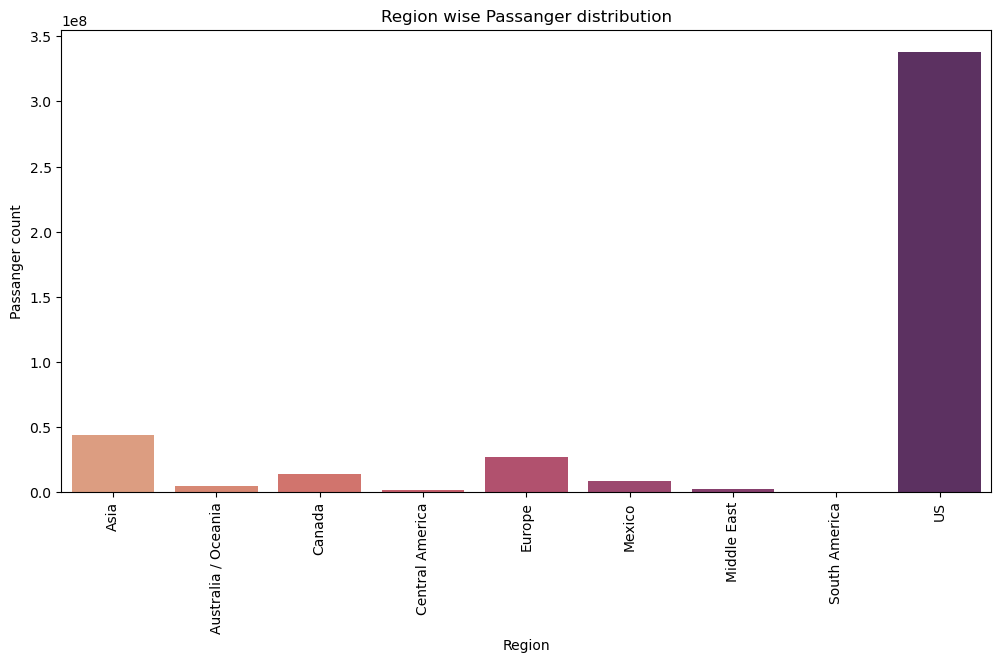

,GEORegion,PassengerCount
0,Asia,43972770
1,Australia / Oceania,4729341
2,Canada,13865159
3,Central America,1355400
4,Europe,26646558
5,Mexico,7998587
6,Middle East,1852943
7,South America,250741
8,US,338141001


In [24]:
plt.figure(figsize=(12,6))
ps=df.groupby('GEORegion')[['PassengerCount']].sum()
sb.barplot(x=ps.index,y=ps.PassengerCount,palette='flare')
plt.title('Region wise Passanger distribution')
plt.xlabel('Region')
plt.ylabel('Passanger count')
plt.xticks(rotation=90)
plt.show()
ps
ps.reset_index()

#### The passenger count of the US is the highest among all GEORegions.
#### Asia and Europe have the next highest passenger counts, but much lower compared to the US.
#### Canada and Mexico show moderate passenger numbers.
#### Australia/Oceania, the Middle East, and Central America have low passenger numbers.
#### South America has the lowest passenger count among all regions.

## Which GEO summary has the highest and lowest passenger traffic?

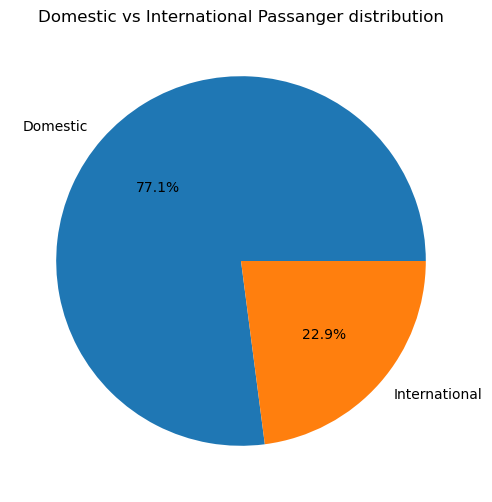

,GEOSummary,PassengerCount
0,Domestic,338141001
1,International,100671499


In [25]:
plt.figure(figsize=(12,6))
q=df.groupby('GEOSummary')[['PassengerCount']].sum().reset_index()
plt.pie(q.PassengerCount,labels=q.GEOSummary,autopct='%1.1f%%')
plt.title('Domestic vs International Passanger distribution')
plt.show()
q

#### The passenger count for domestic travel is much higher than for international travel.
#### Domestic passengers account for approximately 77% of the total.
#### International passengers make up around 23% of the total.

## How do the different activity types (Deplaned, Enplaned) contribute to passenger counts?

In [26]:
df.groupby('ActivityTypeCode')[['PassengerCount']].sum().reset_index()

,ActivityTypeCode,PassengerCount
0,Deplaned,218967525
1,Enplaned,218473395
2,Thru / Transit,1371580


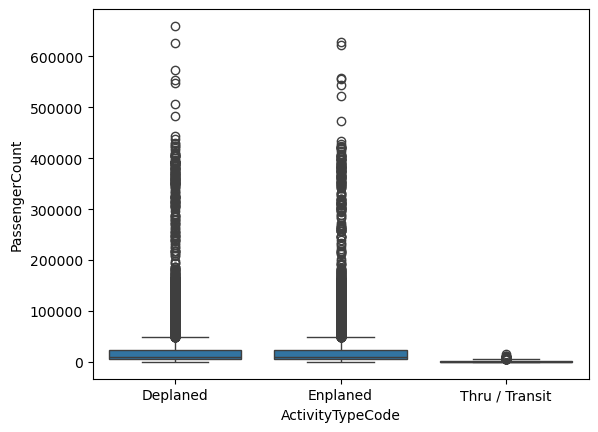

In [27]:
sb.boxplot(x=df.ActivityTypeCode,y=df.PassengerCount)
plt.show()

#### The passenger count for Deplaned and Enplaned activities are almost equal
#### Through/transit passenger numbers are very low, contributing less than 1% of the total.

## Are there specific months or seasons that show peak or low passenger traffic? 

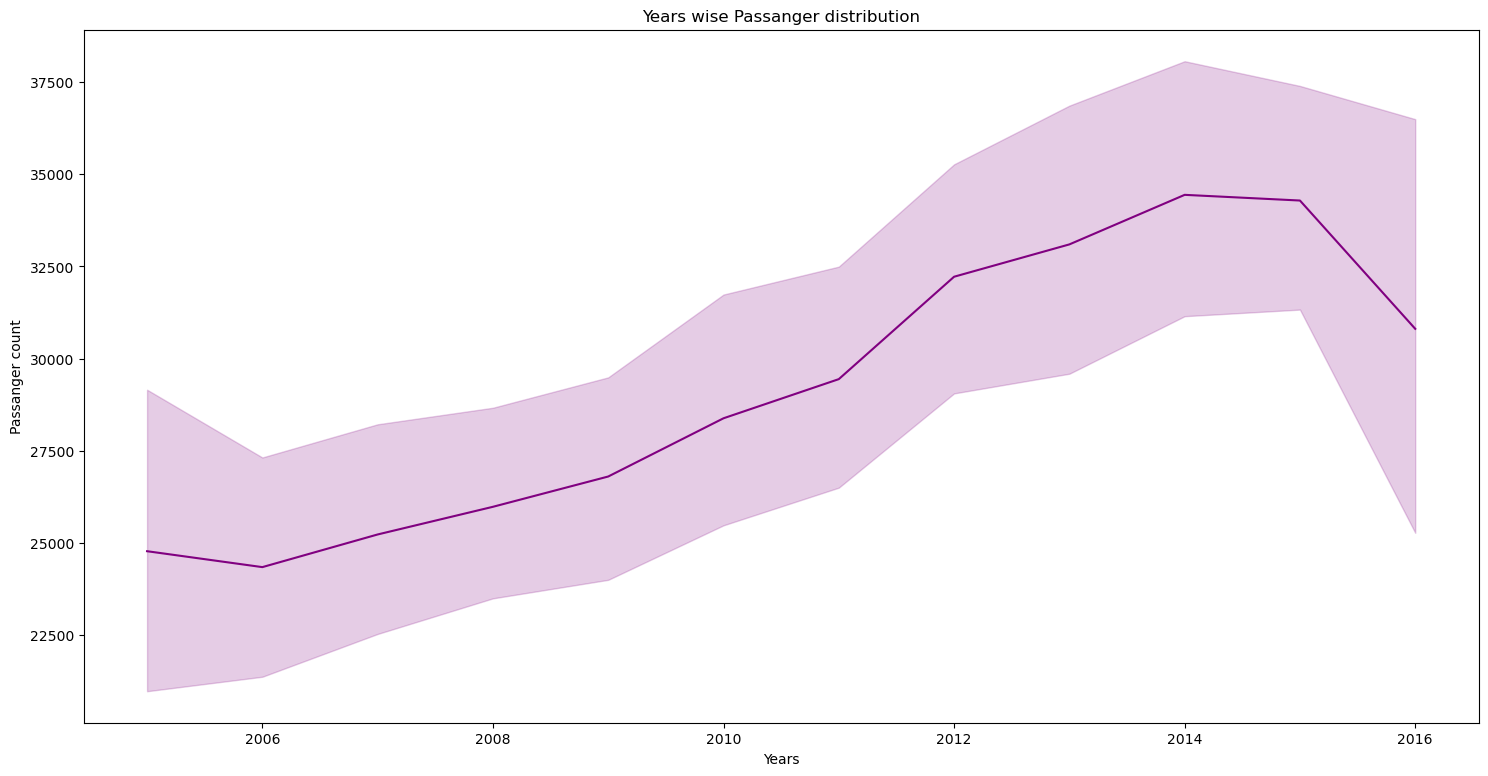

,Year,PassengerCount
0,2015,50057887
1,2014,47114631
2,2013,44945760
3,2012,44399885
4,2011,40927786
5,2010,39253999
6,2009,37338942
7,2008,37234678
8,2007,35554082
9,2006,33332970


In [28]:
p=df.groupby(['Month'])[['PassengerCount']].mean().sort_values(by='PassengerCount',ascending=False).reset_index()
p
plt.figure(figsize=(18,9))
sb.lineplot(x=df.Year,y=df.PassengerCount,color='Purple')
plt.title('Years wise Passanger distribution')
plt.xlabel('Years')
plt.ylabel('Passanger count')
plt.show()
a = df.groupby(['Year'])[['PassengerCount']].sum().nlargest(12,'PassengerCount').reset_index()
a

#### The passenger count shows a steady increase from 2005 to 2015.

#### There is a sharp jump between 2005 (17 million) and 2006 (33 million).

#### From 2006 to 2015, the growth in passengers is consistent year over year.

#### In 2016, the passenger count drops significantly to around 11 million.

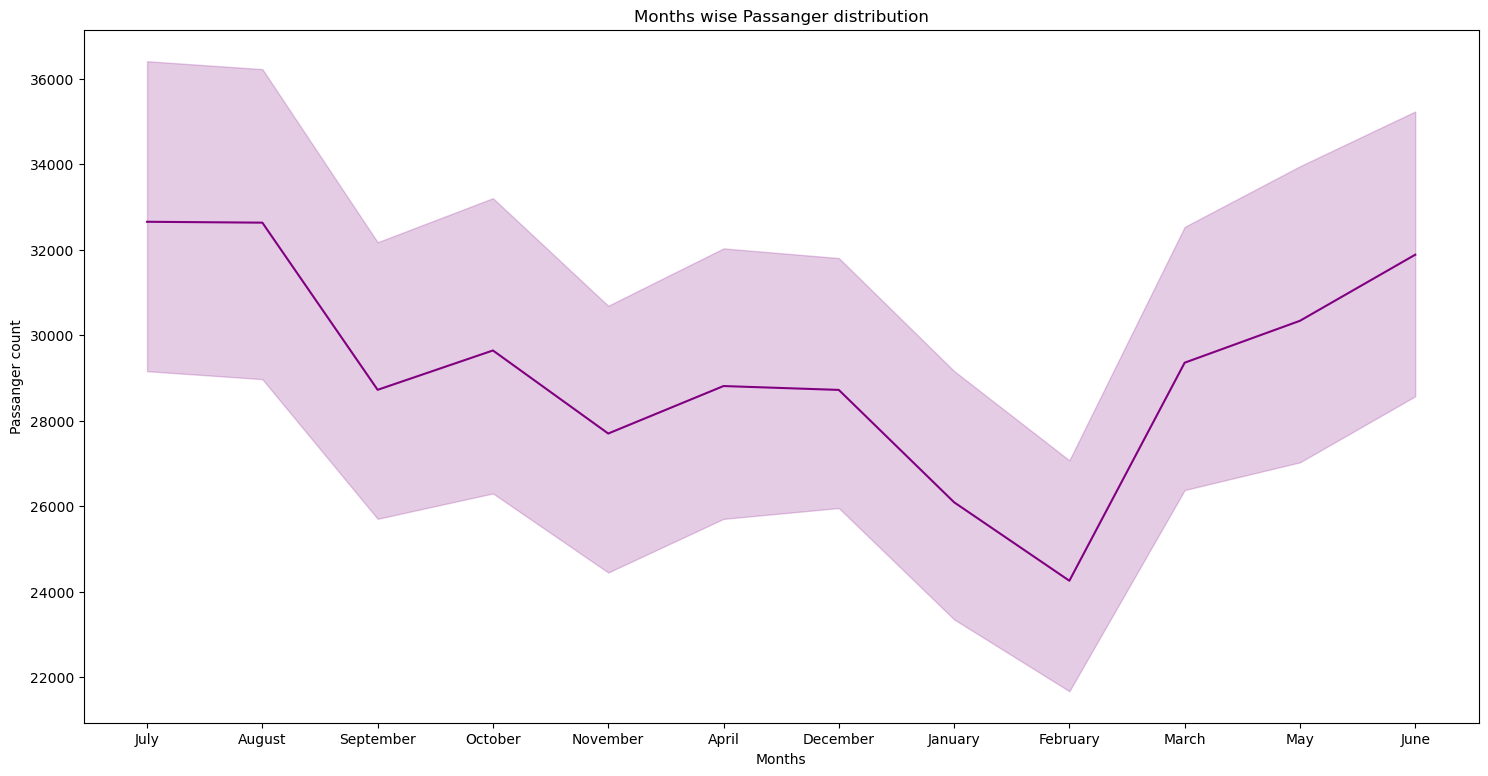

,Month,PassengerCount
0,August,42753659
1,July,42552115
2,October,38391386
3,June,37721908
4,September,37256777
5,March,36787839
6,December,36162507
7,May,35558969
8,November,34988575
9,April,33106801


In [29]:
plt.figure(figsize=(18,9))
sb.lineplot(x=df.Month,y=df.PassengerCount,color='Purple')
plt.title('Months wise Passanger distribution')
plt.xlabel('Months')
plt.ylabel('Passanger count')
plt.show()
df.groupby('Month')[['PassengerCount']].sum().nlargest(12,'PassengerCount').reset_index()

#### Passenger count peaks during the summer months, especially in July and August.

#### Travel activity remains strong in late spring and early fall.

#### Winter months, particularly January and February, see the lowest passenger counts.

#### Overall, the trend shows higher travel during warmer months and a dip during colder months.

In [30]:
c=pd.pivot_table(data=df,index='Year',columns='Month',values='PassengerCount',aggfunc='sum')
c

Month,April,August,December,February,January,July,June,March,May,November,October,September
Year,,,,,,,,,,,,
2005,NaN,3195866.0,2671797.0,NaN,NaN,3225769.0,NaN,NaN,NaN,2617333.0,2770715.0,2740553.0
2006,2773293.0,3143839.0,2698200.0,2223024.0,2448889.0,3227605.0,3071396.0,2708778.0,2829000.0,2653887.0,2834959.0,2720100.0
2007,2869247.0,3436417.0,2903637.0,2304990.0,2507430.0,3382382.0,3263621.0,2820085.0,3056934.0,2922500.0,3129309.0,2957530.0
2008,3029021.0,3612297.0,2962937.0,2595676.0,2670053.0,3603946.0,3453751.0,3127387.0,3305954.0,2744485.0,3124451.0,3004720.0
2009,3024973.0,3650668.0,3074209.0,2359800.0,2644539.0,3649702.0,3419595.0,2925918.0,3177100.0,2971484.0,3249428.0,3191526.0
2010,3139059.0,3771842.0,3167124.0,2515361.0,2785466.0,3765824.0,3612886.0,3105958.0,3380355.0,3163659.0,3490100.0,3356365.0
2011,3200527.0,3917884.0,3441693.0,2610667.0,2883810.0,3935589.0,3766323.0,3129205.0,3547804.0,3326859.0,3602455.0,3564970.0
2012,3563007.0,4356216.0,3443039.0,2998119.0,3211600.0,4284443.0,4107195.0,3472440.0,3820570.0,3478890.0,3844987.0,3819379.0
2013,3604104.0,4347059.0,3814984.0,2966477.0,3204637.0,4176486.0,4146797.0,3593364.0,3933016.0,3466878.0,3910790.0,3781168.0


## How has passenger traffic evolved over the years and months?

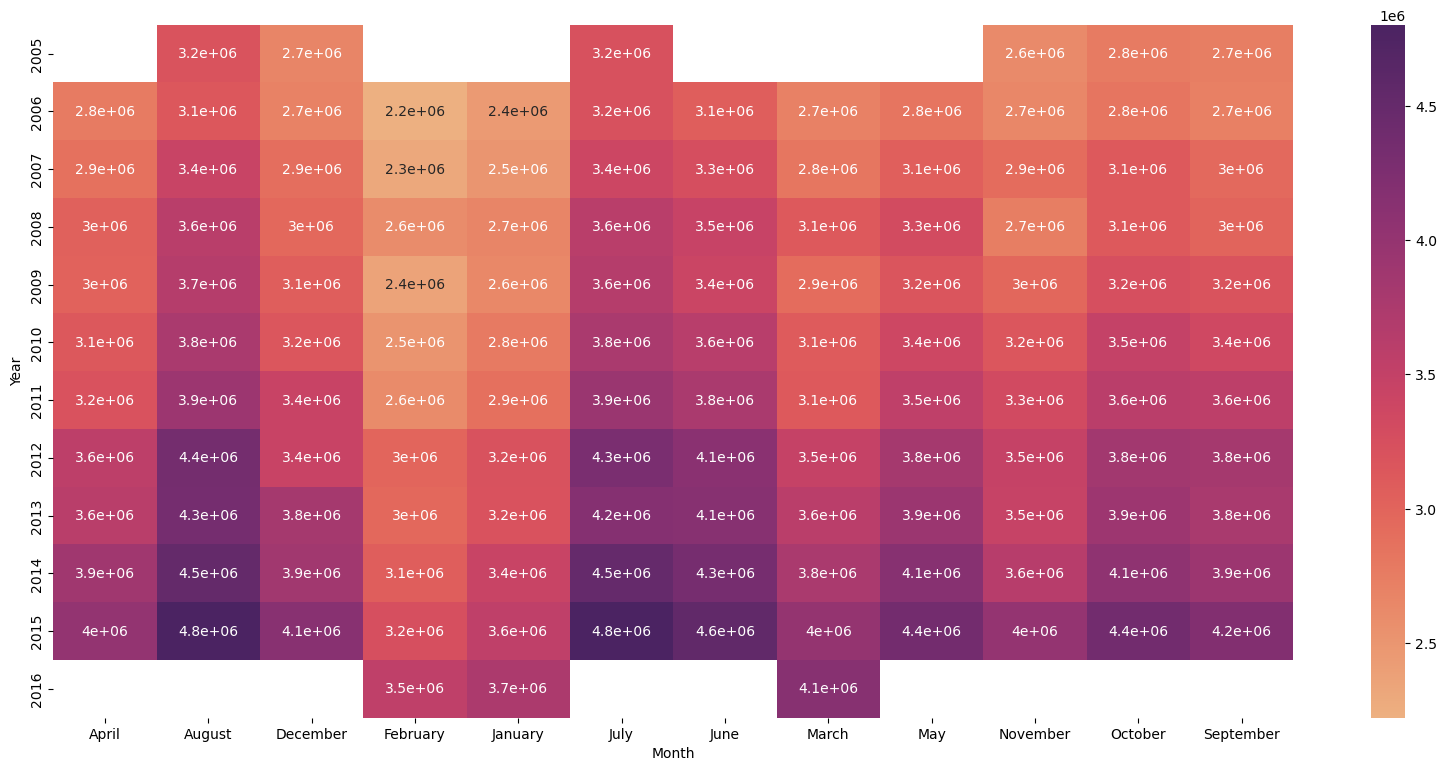

In [31]:
plt.figure(figsize=(20,9))
sb.heatmap(c,annot=True,cmap='flare')
plt.show()

#### Passenger counts steadily increase year over year from 2005 to 2015 across almost all months.

#### July and August consistently have the highest passenger numbers, highlighting peak summer travel.

#### A significant rise is noticeable after 2011, with 2015 showing the highest passenger counts across most months.

#### Data for 2016 is incomplete, but February and March show strong passenger numbers compared to earlier years.

## Which airlines handle the highest and lowest number of passengers?

In [32]:
df.PassengerCount.sum()

438812500

In [33]:
df.groupby('OperatingAirline')[['PassengerCount']].sum().nlargest(10,'PassengerCount').reset_index()

,OperatingAirline,PassengerCount
0,United Airlines,170240913
1,SkyWest Airlines,35711737
2,American Airlines,34588714
3,Virgin America,26934738
4,Delta Air Lines,26440420
5,Southwest Airlines,25087141
6,US Airways,16816616
7,Alaska Airlines,12955980
8,JetBlue Airways,7827973
9,Air Canada,6680071


#### United Airlines (clearly dominant, massive lead)

#### SkyWest Airlines and American Airlines (strong performers, but far behind United)

#### Virgin America, Delta Air Lines, Southwest Airlines (good presence, moderate passenger numbers)

#### US Airways, Alaska Airlines, JetBlue Airways, Air Canada (smaller yet important contributors)

In [34]:
df.groupby('OperatingAirline')[['PassengerCount']].sum().nsmallest(10,'PassengerCount').reset_index()

,OperatingAirline,PassengerCount
0,Evergreen International Airlines,4
1,Boeing Company,18
2,"Atlas Air, Inc",68
3,Ameriflight,110
4,Xtra Airways,146
5,Pacific Aviation,320
6,World Airways,785
7,Miami Air International,1718
8,Servisair,3242
9,Swissport USA,3879


#### These airlines have extremely low passenger counts compared to major carriers.
#### Most are likely cargo operators, charter services, or ground service companies, not regular commercial airlines.
#### Passenger numbers are very minimal, with none crossing even 4,000 passengers.
#### Highlights the clear gap between major commercial airlines and specialized or smaller operators.

## How is passenger traffic distributed among different airlines?

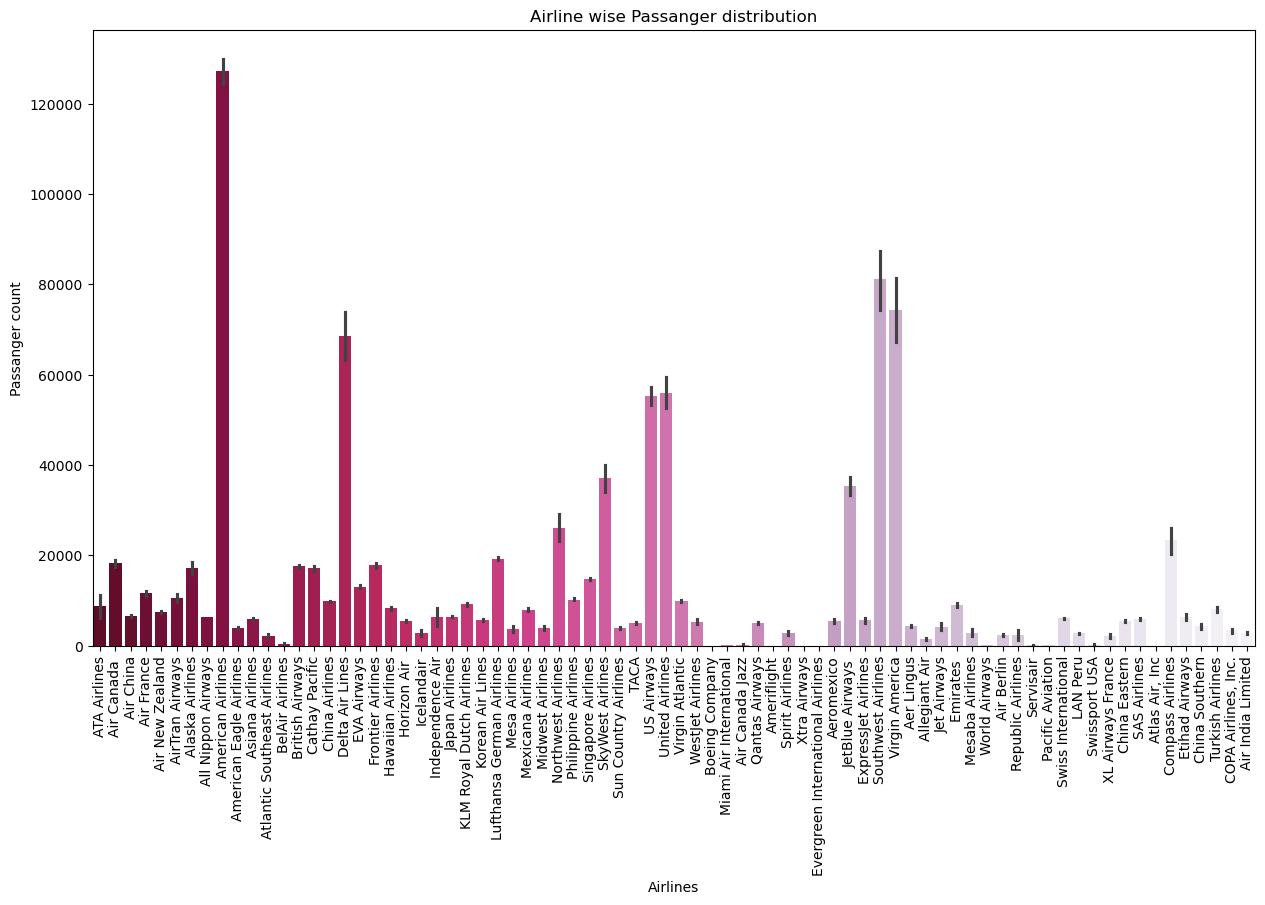

In [35]:
plt.figure(figsize=(15,8))
sb.barplot(x=df.OperatingAirline,y=df.PassengerCount,palette="PuRd_r")
plt.title('Airline wise Passanger distribution')
plt.xlabel('Airlines')
plt.ylabel('Passanger count')
plt.xticks(rotation=90)
plt.show()

#### The top 5 airlines (United Airlines, SkyWest Airlines, American Airlines, Virgin America, and Delta Air Lines) carry the vast majority of passengers with numbers in the tens of millions.
#### Passenger counts are highly concentrated among a few key airlines, with the remaining operators showing minimal activity.
#### A significant gap exists between the top airlines and the smaller ones, as many airlines like Evergreen International, Boeing, and Atlas Air have extremely low passenger counts.

## A regional analysis dashboard of the operating airline.

['US' 'Canada' 'Asia' 'Europe' 'Australia / Oceania' 'Mexico'
 'Central America' 'Middle East' 'South America']


Enter Region Name  Europe


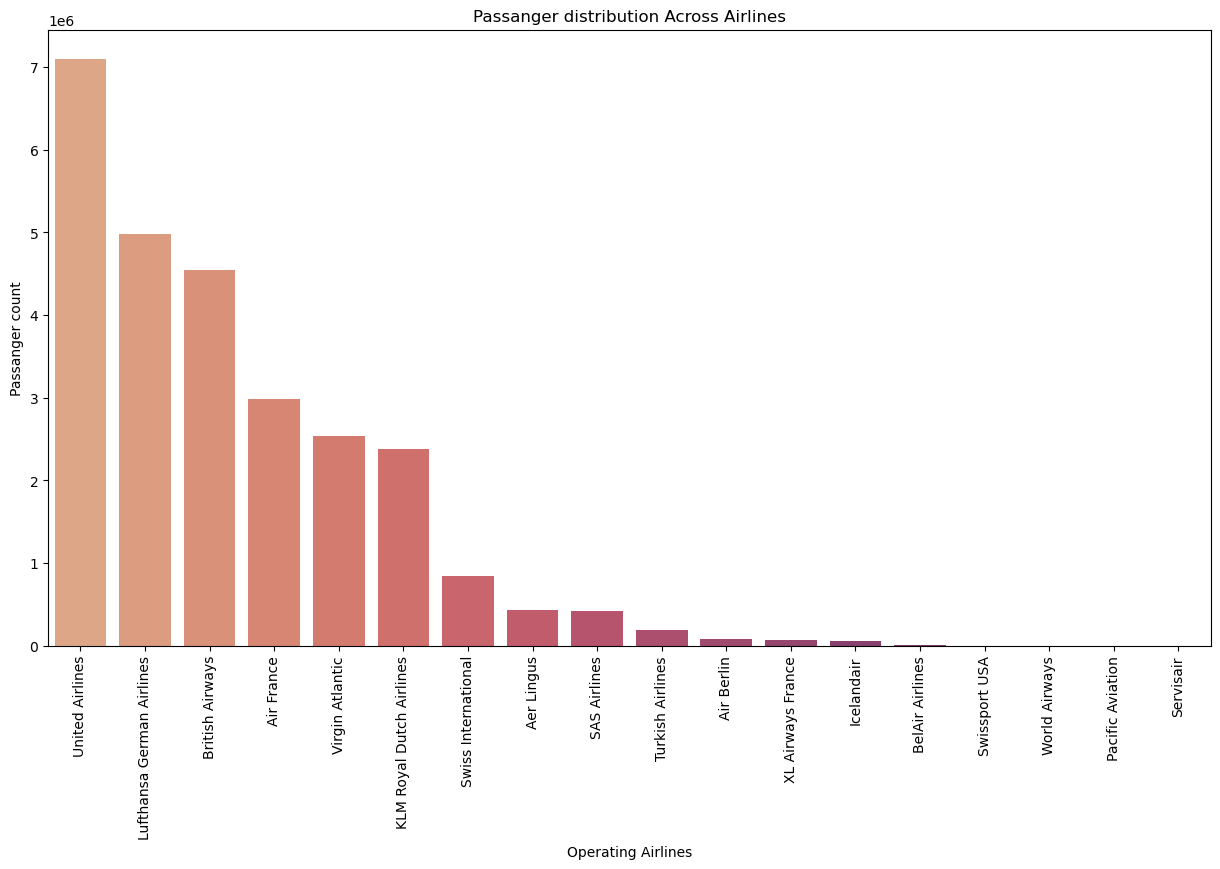

,OperatingAirline,PassengerCount
0,United Airlines,7096837
1,Lufthansa German Airlines,4979907
2,British Airways,4547282
3,Air France,2989982
4,Virgin Atlantic,2540553
5,KLM Royal Dutch Airlines,2379228
6,Swiss International,842568
7,Aer Lingus,431904
8,SAS Airlines,422341
9,Turkish Airlines,195898


In [38]:
print(df.GEORegion.unique())
reg=input("Enter Region Name ")
qq=df[df.GEORegion==reg]
mit = qq.groupby('OperatingAirline')[['PassengerCount']].sum().sort_values(by='PassengerCount',ascending=False)
plt.figure(figsize=(15,8))
sb.barplot(x=mit.index,y=mit.PassengerCount,palette='flare')
plt.title('Passanger distribution Across Airlines')
plt.xlabel('Operating Airlines')
plt.ylabel('Passanger count')
plt.xticks(rotation=90)
plt.show()
mit
mit.reset_index()

## Which terminals and boarding areas are the busiest in terms of passenger traffic?

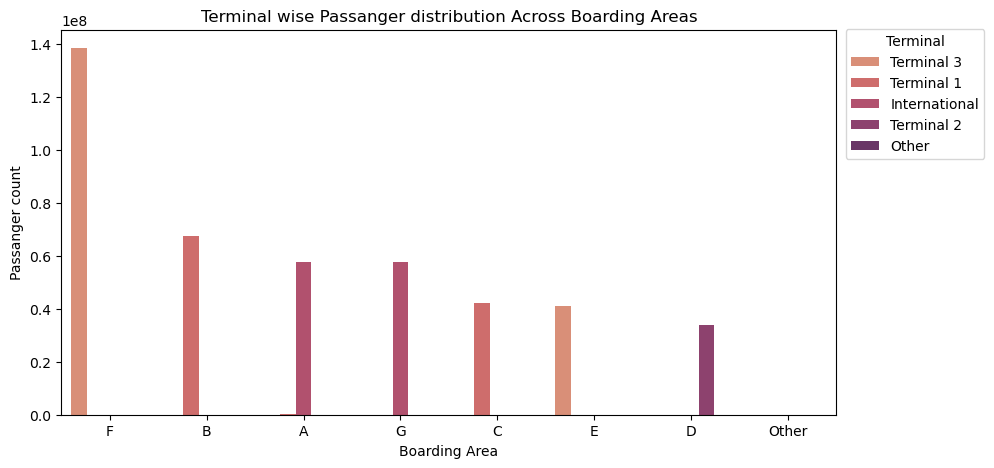

,Terminal,BoardingArea,PassengerCount
8,Terminal 3,F,138526673
4,Terminal 1,B,67373108
0,International,A,57670570
1,International,G,57613844
5,Terminal 1,C,42271640
7,Terminal 3,E,40886909
6,Terminal 2,D,34060240
3,Terminal 1,A,409316
2,Other,Other,200


In [37]:
t=df.groupby(['Terminal','BoardingArea'])[['PassengerCount']].sum().reset_index().sort_values(by='PassengerCount',ascending=False)
plt.figure(figsize=(10,5))
sb.barplot(x=t.BoardingArea,y=t.PassengerCount,hue=t.Terminal,palette='flare')
plt.title('Terminal wise Passanger distribution Across Boarding Areas')
plt.xlabel('Boarding Area')
plt.ylabel('Passanger count')
plt.legend(title='Terminal',bbox_to_anchor=(1.20,1.02))
plt.show()
t

#### Terminal 3 (F) has the highest passenger count, followed by Terminal 1 (B), both showing significantly higher numbers compared to the other terminals.
#### International Terminals (A & G) also handle large volumes of passengers
#### Terminal 1 (C) and Terminal 2 (D) also show moderate passenger traffic, while Terminal 1 (A) and other terminals have very low counts, likely for specialized services or limited operations.
#### The data highlights a clear division in passenger traffic, with certain terminals handling far more passengers than others, particularly international and major domestic terminals.